In [4]:
%pip install -U "pandas>=2.2.0" "numpy>=1.26.0" "matplotlib>=3.8.0" "seaborn>=0.13.2"

import pandas as pd, seaborn as sns
print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
pandas: 3.0.3
seaborn: 0.13.2


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# ============================================================
# PROJECT CONFIG — change global behaviour here, not mid-notebook
# ============================================================

# RC6 fix: pathlib-relative path; no hardcoded personal directory
DATA_PATH = Path("data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/Users/arsalanahmed/Desktop/project/data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "data.csv not found.\n"
        "Fix: place data.csv in the same directory as this notebook.\n"
        f"Tried: {Path('data.csv').resolve()}"
    )

# R7 fix: hardcoded snapshot date — reproducible across runs
# (one day after last transaction 2011-12-09; RFM Recency stays stable
#  even if new rows are appended later)
SNAPSHOT_DATE = pd.Timestamp("2011-12-10")

df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

print("\nData Loaded Successfully \u2705")
print(f"Path used       : {DATA_PATH.resolve()}")
print(f"Shape           : {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Snapshot Date   : {SNAPSHOT_DATE.date()}  (RFM reference \u2014 edit PROJECT CONFIG to change)")



Data Loaded Successfully ✅
Path used       : /Users/arsalanahmed/Desktop/project/data.csv
Shape           : 541,909 rows x 8 columns
Snapshot Date   : 2011-12-10  (RFM reference — edit PROJECT CONFIG to change)


# ============================================================
# SECTION 2: INITIAL DATA EXPLORATION (OVERVIEW)
# ============================================================


In [7]:
print("\n" + "\u2014" * 60)
print("[STEP 2] INITIAL DATA OVERVIEW")
print("\u2014" * 60)

print("\nData Types:")
print(df.dtypes)

print("\nBasic Summary:")
print(df.describe(include="all").transpose())

# 2.1  Standardise / strip string columns
for col in ["InvoiceNo", "StockCode", "Description", "Country"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# 2.2  Authoritative type conversions (RC8 fix: InvoiceDate converted ONCE here;
#      Sections 4.3 and 4.8 no longer re-convert)
if "InvoiceDate" in df.columns:
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
if "CustomerID" in df.columns:
    df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")
if "Quantity" in df.columns:
    df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
if "UnitPrice" in df.columns:
    df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

# 2.3  Quick checks
print("\nDuplicate Rows:", df.duplicated().sum())
if "InvoiceNo"  in df.columns: print("Unique Invoices:", df["InvoiceNo"].nunique())
if "CustomerID" in df.columns:
    print("Unique Customers (incl. NaN):", df["CustomerID"].nunique(dropna=False))
    print("Unique Customers (non-null) :", df["CustomerID"].nunique())
if "Country"    in df.columns:
    print("\nTop Countries:")
    print(df["Country"].value_counts().head(10))

# 2.4  Revenue preview (raw, uncleaned)
if {"Quantity", "UnitPrice"}.issubset(df.columns):
    df["_RevPreview"] = df["Quantity"] * df["UnitPrice"]
    print("\nRevenue Preview (not cleaned):")
    print(df["_RevPreview"].describe())
    df.drop(columns=["_RevPreview"], inplace=True)

print("\nInitial exploration complete \u2705")



————————————————————————————————————————————————————————————
[STEP 2] INITIAL DATA OVERVIEW
————————————————————————————————————————————————————————————

Data Types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Basic Summary:
                count unique                                 top    freq  \
InvoiceNo      541909  25900                              573585    1114   
StockCode      541909   4070                              85123A    2313   
Description    540455   4223  WHITE HANGING HEART T-LIGHT HOLDER    2369   
Quantity     541909.0    NaN                                 NaN     NaN   
InvoiceDate    541909  23260                    10/31/2011 14:41    1114   
UnitPrice    541909.0    NaN                                 NaN     NaN   
CustomerID   406829.0    NaN                                 NaN     NaN   
Country    

# ------------------------------------------------------------
# SECTION 3: DATA QUALITY AUDIT
# ------------------------------------------------------------


In [8]:
print("\n[STEP 3] Data Quality Assessment (raw data \u2014 pre-cleaning)...")

# 3.1  Missing values
total_rows   = len(df)
missing_cust = df["CustomerID"].isnull().sum()
missing_desc = df["Description"].isnull().sum()
pct_cust     = missing_cust / total_rows * 100
pct_desc     = missing_desc / total_rows * 100

print("\u2014\u2014 Data Quality Audit (raw, pre-cleaning) \u2014\u2014")
print(f"Total Rows          : {total_rows:,}")
print(f"Missing CustomerID  : {missing_cust:,} rows ({pct_cust:.2f}%)")
print(f"Missing Description : {missing_desc:,} rows ({pct_desc:.2f}%)")
if pct_cust > 0:
    print(f"\n\u2192 Decision: will drop {missing_cust:,} rows with no CustomerID in Section 4")

# 3.2  Cancellation rate
# RC2 fix: clearly labelled as PRE-CLEANING (not the post-clean business rate)
# R6  fix: np.where replaces apply(lambda) \u2014 vectorised and ~100x faster
unique_orders = df[["InvoiceNo"]].drop_duplicates().copy()
unique_orders["Status"] = np.where(
    unique_orders["InvoiceNo"].astype(str).str.upper().str.startswith("C"),
    "Canceled",
    "Completed",
)
status_counts     = unique_orders["Status"].value_counts()
cancellation_rate = status_counts.get("Canceled", 0) / len(unique_orders) * 100

print("\nOrder Status Summary (raw unique invoices, pre-cleaning):")
print(status_counts)
print(f"Pre-Cleaning Cancellation Rate: {cancellation_rate:.1f}%")
print("Note: computed on raw data \u2014 includes duplicates and null-CustomerID rows.")



[STEP 3] Data Quality Assessment (raw data — pre-cleaning)...
—— Data Quality Audit (raw, pre-cleaning) ——
Total Rows          : 541,909
Missing CustomerID  : 135,080 rows (24.93%)
Missing Description : 1,454 rows (0.27%)

→ Decision: will drop 135,080 rows with no CustomerID in Section 4

Order Status Summary (raw unique invoices, pre-cleaning):
Status
Completed    22064
Canceled      3836
Name: count, dtype: int64
Pre-Cleaning Cancellation Rate: 14.8%
Note: computed on raw data — includes duplicates and null-CustomerID rows.


# ------------------------------------------------------------
# SECTION 4: UNIFIED DATA CLEANING
# ------------------------------------------------------------


In [9]:
print("\n[STEP 4] Cleaning Data...")

# RC1 fix: remove 5,268 exact duplicate rows
# (Section 2 detected them but no drop_duplicates() call existed anywhere;
#  all downstream RFM metrics were inflated)
pre_dedup = len(df)
df = df.drop_duplicates().copy()
print(f"\u2192 Removed {pre_dedup - len(df):,} exact duplicate rows")

# 4.1  Drop rows with missing CustomerID
df = df.dropna(subset=["CustomerID"]).copy()
print("\u2192 Removed rows with missing CustomerID")

# 4.1b Remove cancelled invoices (InvoiceNo starts with 'C')
df = df[~df["InvoiceNo"].astype(str).str.upper().str.startswith("C")].copy()
print("\u2192 Removed cancelled invoices (InvoiceNo starts with 'C')")

# 4.2  Remove non-positive quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
print("\u2192 Removed rows with Quantity \u2264 0 or UnitPrice \u2264 0")

# 4.3  Drop unparseable dates; cast CustomerID to int
# RC8 fix: InvoiceDate already converted in Section 2 \u2014 no pd.to_datetime call here
df = df.dropna(subset=["InvoiceDate"]).copy()
df["CustomerID"] = df["CustomerID"].astype(int)
print("\u2192 Dropped unparseable InvoiceDate rows; cast CustomerID to int")

# 4.4  Create Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
print("\u2192 Created Revenue column")

# 4.5  Remove non-product codes (postage, fees, etc.)
non_product_codes = ["POST", "D", "M", "PADS", "DOT", "CRUK"]
df = df[~df["StockCode"].isin(non_product_codes)]
df = df[~df["Description"].isin(["AMAZON FEE", "Manual", "Bank Charges"])]
print("\u2192 Filtered out postage and service charges")



[STEP 4] Cleaning Data...
→ Removed 5,268 exact duplicate rows
→ Removed rows with missing CustomerID
→ Removed cancelled invoices (InvoiceNo starts with 'C')
→ Removed rows with Quantity ≤ 0 or UnitPrice ≤ 0
→ Dropped unparseable InvoiceDate rows; cast CustomerID to int
→ Created Revenue column
→ Filtered out postage and service charges


In [10]:
# 4.6  OUTLIER DETECTION (IQR METHOD)
print("\n\u2014\u2014 Outlier Detection (IQR Method) \u2014\u2014")
initial_rows = len(df)
initial_rev  = df["Revenue"].sum()

Q1          = df["Quantity"].quantile(0.25)
Q3          = df["Quantity"].quantile(0.75)
IQR         = Q3 - Q1
upper_bound = Q3 + (3 * IQR)

df["IsQtyOutlier"] = df["Quantity"] > upper_bound
out_rows = df["IsQtyOutlier"].sum()
out_rev  = df.loc[df["IsQtyOutlier"], "Revenue"].sum()

print(f"Upper Bound    : {upper_bound:.0f}")
print(f"Outlier rows   : {out_rows:,} ({out_rows / initial_rows:.2%})")
print(f"Outlier revenue: \u00a3{out_rev:,.2f} ({out_rev / initial_rev:.2%})")

# Outlier-free copy for visualisations that require it
df_viz = df.loc[~df["IsQtyOutlier"]].copy()

# RC3 fix: drop the sentinel column from df immediately
# (without this, the boolean column leaks into every downstream groupby/agg)
df.drop(columns=["IsQtyOutlier"], inplace=True)
print("\u2192 IsQtyOutlier flag removed from df (outlier-free view stored in df_viz)")

# 4.7  Time-grain feature
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
print("\u2192 Created YearMonth column")



—— Outlier Detection (IQR Method) ——
Upper Bound    : 42
Outlier rows   : 18,495 (4.73%)
Outlier revenue: £3,152,242.28 (36.05%)
→ IsQtyOutlier flag removed from df (outlier-free view stored in df_viz)
→ Created YearMonth column


In [11]:
# 4.8  Customer type classification (idempotent)
print("\n[STEP 4.8] Customer type classification (New vs Returning)")

# RC8 fix: third redundant pd.to_datetime call removed
# (InvoiceDate already datetime from Section 2)
df["FirstPurchaseDate"] = df.groupby("CustomerID")["InvoiceDate"].transform("min")

# Vectorised \u2014 no apply
df["CustomerType"] = np.where(
    df["InvoiceDate"].dt.normalize() == df["FirstPurchaseDate"].dt.normalize(),
    "New Customer",
    "Returning Customer",
)
print("\u2192 Classified customers (New vs Returning)")



[STEP 4.8] Customer type classification (New vs Returning)
→ Classified customers (New vs Returning)


# ------------------------------------------------------------
# SECTION 5: RFM CALCULATION
# ------------------------------------------------------------


In [12]:
print("\n" + "\u2014" * 60)
print("[STEP 5] RFM CALCULATION")
print("\u2014" * 60)

# R7 fix: use hardcoded SNAPSHOT_DATE from PROJECT CONFIG
# (not recomputed from data \u2014 Recency values stay stable across data refreshes)
print(f"\nSnapshot Date: {SNAPSHOT_DATE.date()}")

# Aggregate per customer
rfm = (
    df.groupby("CustomerID")
    .agg(
        LastDate  = ("InvoiceDate", "max"),
        Frequency = ("InvoiceNo",   "nunique"),
        Monetary  = ("Revenue",     "sum"),
    )
    .reset_index()
)

# R2 fix: fully vectorised Recency \u2014 no per-group lambda inside agg()
rfm["Recency"] = (SNAPSHOT_DATE - rfm["LastDate"].dt.normalize()).dt.days
rfm = rfm.drop(columns=["LastDate"])
rfm = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]]

print("\nRFM Calculation Complete:")
print(f"\u2192 Total customers : {len(rfm):,}")
print(f"\u2192 Recency range   : {rfm['Recency'].min():.0f} \u2013 {rfm['Recency'].max():.0f} days")
print(f"\u2192 Frequency range : {rfm['Frequency'].min():.0f} \u2013 {rfm['Frequency'].max():.0f} transactions")
print(f"\u2192 Monetary range  : \u00a3{rfm['Monetary'].min():.2f} \u2013 \u00a3{rfm['Monetary'].max():.2f}")

print("\nRFM Summary Statistics:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))

print("\nFirst 10 customers (RFM):")
print(rfm.head(10))



————————————————————————————————————————————————————————————
[STEP 5] RFM CALCULATION
————————————————————————————————————————————————————————————

Snapshot Date: 2011-12-10

RFM Calculation Complete:
→ Total customers : 4,334
→ Recency range   : 1 – 374 days
→ Frequency range : 1 – 206 transactions
→ Monetary range  : £3.75 – £279138.02

RFM Summary Statistics:
       Recency  Frequency   Monetary
count  4334.00    4334.00    4334.00
mean     93.23       4.25    2017.52
std     100.18       7.64    8920.36
min       1.00       1.00       3.75
25%      18.00       1.00     304.30
50%      51.00       2.00     663.71
75%     143.00       5.00    1631.62
max     374.00     206.00  279138.02

First 10 customers (RFM):
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        3          7   4310.00
2       12348       76          4   1437.24
3       12349       19          1   1457.55
4       12350      311          1    294.40
5       12

# ------------------------------------------------------------
# SECTION 6: RFM SCORING & SEGMENTATION
# ------------------------------------------------------------


In [22]:
print("\n" + "\u2014" * 60)
print("[STEP 6] RFM SCORING & SEGMENTATION")
print("\u2014" * 60)
# N3 / R1 fix: removed redundant `import numpy as np` and `import pandas as pd`
# (both already imported once in Section 1)

# ── PART 6.1: Robust R/F/M scoring ───────────────────────────────────────
def qcut_scores(series, q, higher_is_better):
    """Quantile-bin a series into 1..q integer scores; higher score = better.

    Tie-safe: ranks with method='dense' before pd.qcut so duplicate
    values never produce duplicate bin edges that crash the binning.
    Automatically reduces bin count when fewer unique values exist.
    ascending=higher_is_better routes both directions without an if-branch.
    """
    k = min(q, int(series.dropna().nunique()))
    if k < 2:
        return pd.Series(1, index=series.index, dtype=int)
    ranked = series.rank(method="dense", ascending=higher_is_better)
    binned = pd.qcut(ranked, q=k, labels=False, duplicates="drop")
    return (binned.astype("float") + 1).astype("Int64").fillna(1).astype(int)

rfm["R_Score"]   = qcut_scores(rfm["Recency"],   q=5, higher_is_better=False)
rfm["F_Score"]   = qcut_scores(rfm["Frequency"], q=5, higher_is_better=True)
rfm["M_Score"]   = qcut_scores(rfm["Monetary"],  q=5, higher_is_better=True)
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

print("\nRFM Scoring Complete \u2705  (higher = better for R, F, M)")
print(f"\u2192 RFM_Score range : {rfm['RFM_Score'].min()} \u2013 {rfm['RFM_Score'].max()}")
print(f"Score bin counts : R={rfm['R_Score'].nunique()} | F={rfm['F_Score'].nunique()} | M={rfm['M_Score'].nunique()}")
print("\nSample RFM Scores:")
print(rfm[["CustomerID","Recency","Frequency","Monetary",
           "R_Score","F_Score","M_Score","RFM_Score"]].head(10))

# ── PART 6.2: Segmentation thresholds ────────────────────────────────────
m25 = rfm["Monetary"].quantile(0.25)
m75 = rfm["Monetary"].quantile(0.75)
m90 = rfm["Monetary"].quantile(0.90)

# interpolation= is still the correct param for Series.quantile()
p80_f = rfm["Frequency"].quantile(0.80, interpolation="higher")
f_cut = int(p80_f)

print("\nThresholds used for segmentation:")
print(f"Frequency P80 (interpolation=higher) : {p80_f} \u2192 f_cut = {f_cut}")
print(f"Monetary P25 : \u00a3{m25:,.2f}  |  P75: \u00a3{m75:,.2f}  |  P90: \u00a3{m90:,.2f}")

share_freq = (rfm["Frequency"] >= f_cut).mean() * 100
share_m90  = (rfm["Monetary"]  >= m90 ).mean() * 100
share_r30  = (rfm["Recency"]   <= 30  ).mean() * 100
print(f"\nSanity \u2014 threshold coverage:")
print(f"  Frequency \u2265 {f_cut}       : {share_freq:.1f}% of customers")
print(f"  Monetary  \u2265 P90 (\u00a3{m90:,.0f}): {share_m90:.1f}% of customers")
print(f"  Recency   \u2264 30 days     : {share_r30:.1f}% of customers")

# ── PART 6.3: Segmentation \u2014 fully vectorised with np.select ─────────────
#
# RC9 fix: replaced row-wise apply(segment_customer, axis=1) with np.select
#          (~100x faster; eliminates one Python function call per customer row)
#
# N4  fix: added 'High-Value New' segment
#   Previously, customers like ID 16446 (Recency=1, Frequency=2, Monetary=\u00a3168K)
#   fell through to 'Recent Customers' because they didn't meet the Frequency >= f_cut
#   threshold for Champions. Yet they sit in Decile 1. The 'High-Value New' rule
#   catches any recent buyer whose spend already exceeds P90, regardless of order count.
#
# Rules are evaluated in priority order; FIRST matching condition wins.
# ─────────────────────────────────────────────────────────────────────────
conditions = [
    # 1. Champions: very recent + frequent + very high spend
    (rfm["Recency"] <= 30)  & (rfm["Frequency"] >= f_cut) & (rfm["Monetary"] >= m90),
    # 2. High-Value New: recent + extreme spend, not yet frequent (N4 fix)
    (rfm["Recency"] <= 30)  & (rfm["Monetary"] >= m90),
    # 3. Loyal Customers: recent + frequent
    (rfm["Recency"] <= 60)  & (rfm["Frequency"] >= f_cut),
    # 4. Recent Customers: very recent (catches remaining low-freq recent buyers)
    (rfm["Recency"] <= 30),
    # 5. At Risk: lapsed but historically high activity or spend
    (rfm["Recency"] >= 120) & ((rfm["Frequency"] >= f_cut) | (rfm["Monetary"] >= m75)),
    # 6. Hibernating: long inactive + low frequency + low spend
    (rfm["Recency"] >= 180) & (rfm["Frequency"] <= 2) & (rfm["Monetary"] <= m25),
]
choices = [
    "Champions",
    "High-Value New",
    "Loyal Customers",
    "Recent Customers",
    "At Risk",
    "Hibernating",
]
rfm["Segment"] = np.select(conditions, choices, default="Needs Attention")

# RC4 fix: removed vacuous assertion (value_counts().sum() == len(rfm) is always True
#          when no NaN \u2014 it caught nothing). Only the isna check is meaningful.
assert rfm["Segment"].isna().sum() == 0, "Some rows did not receive a segment"

print("\nSegmentation Rules Applied \u2705  (vectorised np.select)")
print("\u2192 Champions       : Recency\u226430  AND Frequency\u2265P80 AND Monetary\u2265P90")
print("\u2192 High-Value New  : Recency\u226430  AND Monetary\u2265P90  (N4 fix)")
print("\u2192 Loyal Customers : Recency\u226460  AND Frequency\u2265P80")
print("\u2192 Recent Customers: Recency\u226430")
print("\u2192 At Risk         : Recency\u2265120 AND (Frequency\u2265P80 OR Monetary\u2265P75)")
print("\u2192 Hibernating     : Recency\u2265180 AND Frequency\u22642 AND Monetary\u2264P25")
print("\u2192 Needs Attention : everything else")

print("\nSegment Distribution:")
print(rfm["Segment"].value_counts())

seg_perf = (
    rfm.groupby("Segment")
    .agg(
        Customers  = ("CustomerID", "count"),
        Revenue    = ("Monetary",   "sum"),
        AvgRevenue = ("Monetary",   "mean"),
        AvgRecency = ("Recency",    "mean"),
        AvgFreq    = ("Frequency",  "mean"),
    )
    .sort_values("Revenue", ascending=False)
)
seg_perf["Revenue_%"] = (seg_perf["Revenue"] / seg_perf["Revenue"].sum() * 100).round(1)
print("\nSegment Performance Summary:")
print(seg_perf.round(2))



————————————————————————————————————————————————————————————
[STEP 6] RFM SCORING & SEGMENTATION
————————————————————————————————————————————————————————————

RFM Scoring Complete ✅  (higher = better for R, F, M)
→ RFM_Score range : 3 – 14
Score bin counts : R=5 | F=4 | M=5

Sample RFM Scores:
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      326          1  77183.60        1        1        5   
1       12347        3          7   4310.00        5        4        5   
2       12348       76          4   1437.24        2        3        4   
3       12349       19          1   1457.55        4        1        4   
4       12350      311          1    294.40        1        1        2   
5       12352       37          7   1385.74        3        4        4   
6       12353      205          1     89.00        1        1        1   
7       12354      233          1   1079.40        1        1        4   
8       12355      215          1    4

# ------------------------------------------------------------
# SECTION 7: SEGMENT ANALYSIS
# ------------------------------------------------------------


In [23]:
print("\n" + "\u2014" * 60)
print("[STEP 7] SEGMENT ANALYSIS + PARETO (CUSTOMER-LEVEL)")
print("\u2014" * 60)
# N3 / R1 fix: removed redundant `import numpy as np`

# R4 fix: pre-drop all columns that will be merged in below.
# Eliminates the fragile suffixes=('', '_new') + manual reconciliation pattern
# that was used twice and would silently break on any column rename.
rfm.drop(
    columns=["ActiveMonths", "OrdersPerMonth", "TenureMonths", "OrdersPerTenureMonth"],
    errors="ignore",
    inplace=True,
)

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

# 7.1  ActiveMonths + OrdersPerMonth
cust_months = (
    df.drop_duplicates(["CustomerID", "YearMonth"])
    .groupby("CustomerID")
    .size()
    .rename("ActiveMonths")
    .reset_index()
)
rfm = rfm.merge(cust_months, on="CustomerID", how="left")
rfm["ActiveMonths"]   = rfm["ActiveMonths"].fillna(1).astype(int).clip(lower=1)
rfm["OrdersPerMonth"] = (rfm["Frequency"] / rfm["ActiveMonths"]).round(2)

# 7.2  TenureMonths + OrdersPerTenureMonth
tenure = (
    df.groupby("CustomerID")
    .agg(FirstDate=("InvoiceDate", "min"), LastDate=("InvoiceDate", "max"))
    .reset_index()
)

# Vectorised month-diff \u2014 replaces apply(lambda x: x.n) on Period offset objects
tenure["TenureMonths"] = (
    (tenure["LastDate"].dt.year  - tenure["FirstDate"].dt.year) * 12
    + (tenure["LastDate"].dt.month - tenure["FirstDate"].dt.month)
    + 1
).astype(int)

rfm = rfm.merge(tenure[["CustomerID", "TenureMonths"]], on="CustomerID", how="left")
rfm["TenureMonths"]         = rfm["TenureMonths"].fillna(1).astype(int).clip(lower=1)
rfm["OrdersPerTenureMonth"] = (rfm["Frequency"] / rfm["TenureMonths"]).round(2)

# 7.3  Segment Summary
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers                = ("CustomerID",            "count"),
        Avg_Monetary             = ("Monetary",              "mean"),
        Median_Monetary          = ("Monetary",              "median"),
        Total_Monetary           = ("Monetary",              "sum"),
        Avg_Recency              = ("Recency",               "mean"),
        Avg_Frequency            = ("Frequency",             "mean"),
        Avg_ActiveMonths         = ("ActiveMonths",          "mean"),
        Avg_OrdersPerMonth       = ("OrdersPerMonth",        "mean"),
        Avg_TenureMonths         = ("TenureMonths",          "mean"),
        Avg_OrdersPerTenureMonth = ("OrdersPerTenureMonth",  "mean"),
    )
    .round(2)
)
segment_summary = segment_summary.sort_values("Total_Monetary", ascending=False)
segment_summary["Customer_%"] = (
    segment_summary["Customers"] / segment_summary["Customers"].sum() * 100
).round(1)
segment_summary["Revenue_%"] = (
    segment_summary["Total_Monetary"] / segment_summary["Total_Monetary"].sum() * 100
).round(1)

print("\nSegment Summary:")
print(segment_summary)

# 7.4  Pareto Analysis
print("\n\u2014\u2014 Pareto Analysis (customer-level) \u2014\u2014")
rfm_sorted    = rfm.sort_values("Monetary", ascending=False).reset_index(drop=True)
n             = len(rfm_sorted)
total_rev     = rfm_sorted["Monetary"].sum()
top10_rev_pct = rfm_sorted.loc[:int(np.ceil(n * 0.10)) - 1, "Monetary"].sum() / total_rev * 100
top20_rev_pct = rfm_sorted.loc[:int(np.ceil(n * 0.20)) - 1, "Monetary"].sum() / total_rev * 100

print(f"\u2192 Top 10% customers: {top10_rev_pct:.1f}% of revenue")
print(f"\u2192 Top 20% customers: {top20_rev_pct:.1f}% of revenue")
print(f"\u2192 Pareto check (\u226575% from top 20%): {top20_rev_pct >= 75}")
print("\nNote: OrdersPerMonth uses ActiveMonths (months with \u22651 purchase).")
print("      OrdersPerTenureMonth uses first\u2192last month span \u2014 stronger habit metric.")



————————————————————————————————————————————————————————————
[STEP 7] SEGMENT ANALYSIS + PARETO (CUSTOMER-LEVEL)
————————————————————————————————————————————————————————————

Segment Summary:
                  Customers  Avg_Monetary  Median_Monetary  Total_Monetary  \
Segment                                                                      
Champions               323      13494.76          6050.69      4358806.37   
Needs Attention        2000        775.18           512.76      1550356.48   
Loyal Customers         639       2369.91          2039.58      1514370.95   
Recent Customers        830        756.19           597.28       627633.81   
At Risk                  90       4071.95          2016.40       366475.89   
High-Value New           17      14873.37          4628.75       252847.23   
Hibernating             435        168.79           160.54        73422.91   

                  Avg_Recency  Avg_Frequency  Avg_ActiveMonths  \
Segment                               

# ------------------------------------------------------------
# SECTION 8: DECILE ANALYSIS
# ------------------------------------------------------------


In [24]:
print("\n" + "\u2014" * 60)
print("[STEP 8] DECILE ANALYSIS")
print("\u2014" * 60)

# 8.1  Create deciles (D1 = top 10% spenders, D10 = bottom 10%)
rfm["Decile"] = pd.qcut(
    rfm["Monetary"],
    q=10,
    labels=list(range(10, 0, -1)),
    duplicates="drop",
).astype(int)

deciles = (
    rfm.groupby("Decile")["Monetary"]
    .agg(TotalRevenue="sum", AvgRevenue="mean", CustomerCount="count")
    .round(2)
)

# 8.2  Sort D1 first; compute Pareto metrics
# R3 fix: removed CP_Revenue_% \u2014 it was an identical copy of CumRevenue_% with a different name
deciles = deciles.sort_index(ascending=True)
deciles["Revenue_%"]    = (deciles["TotalRevenue"] / deciles["TotalRevenue"].sum() * 100).round(1)
deciles["CumRevenue_%"] = deciles["Revenue_%"].cumsum().round(1)

print("\nDecile Summary (D1 = Top 10% Spenders, D10 = Bottom 10%):")
print(deciles)

top_decile_pct = deciles.loc[1, "Revenue_%"]
print("\n\u2014\u2014 Decile Pareto Analysis \u2014\u2014")
print(f"\u2192 D1 (top 10% of customers): {top_decile_pct:.1f}% of revenue")
print(f"\u2192 Pareto Validation (\u226545% from D1): {top_decile_pct >= 45}")

print("\nSanity \u2014 AvgRevenue should decrease D1\u2192D10:")
print(deciles["AvgRevenue"])
print(f"\nSanity \u2014 CumRevenue_% last value (should be ~100): {deciles['CumRevenue_%'].iloc[-1]}")



————————————————————————————————————————————————————————————
[STEP 8] DECILE ANALYSIS
————————————————————————————————————————————————————————————

Decile Summary (D1 = Top 10% Spenders, D10 = Bottom 10%):
        TotalRevenue  AvgRevenue  CustomerCount  Revenue_%  CumRevenue_%
Decile                                                                  
1         5367628.87    12396.37            433       61.4          61.4
2         1156125.11     2663.88            434       13.2          74.6
3          713763.83     1648.42            433        8.2          82.8
4          482459.71     1111.66            434        5.5          88.3
5          338005.32      780.61            433        3.9          92.2
6          248096.19      572.97            433        2.8          95.0
7          176619.01      406.96            434        2.0          97.0
8          130087.95      300.43            433        1.5          98.5
9           85519.73      197.51            433        1.0     

# ------------------------------------------------------------
# Section 9: TOP CUSTOMERS
# ------------------------------------------------------------


In [25]:
print("\n" + "\u2014" * 60)
print("[STEP 9] TOP CUSTOMERS")
print("\u2014" * 60)

top_customers = (
    rfm.sort_values("Monetary", ascending=False)
    .loc[:, ["CustomerID", "Recency", "Frequency", "Monetary", "Segment", "Decile"]]
    .head(20)
)
print("\nTop 20 Customers by Monetary Value:")
print(top_customers.to_string(index=False))



————————————————————————————————————————————————————————————
[STEP 9] TOP CUSTOMERS
————————————————————————————————————————————————————————————

Top 20 Customers by Monetary Value:
 CustomerID  Recency  Frequency  Monetary         Segment  Decile
      14646        2         72 279138.02       Champions       1
      18102        1         60 259657.30       Champions       1
      17450        9         46 194390.79       Champions       1
      16446        1          2 168472.50  High-Value New       1
      14911        2        199 140336.83       Champions       1
      12415       25         20 124564.53       Champions       1
      14156       10         55 117210.08       Champions       1
      17511        3         31  91062.38       Champions       1
      12346      326          1  77183.60         At Risk       1
      16029       39         62  72708.09 Loyal Customers       1
      16684        5         28  66653.56       Champions       1
      13694        4     

# ------------------------------------------------------------
# SECTION 10: EXPLORATORY VISUALIZATIONS
# ------------------------------------------------------------



————————————————————————————————————————————————————————————
[STEP 10] EXPLORATORY VISUALIZATIONS
————————————————————————————————————————————————————————————

→ Creating Monthly Revenue Trend chart...


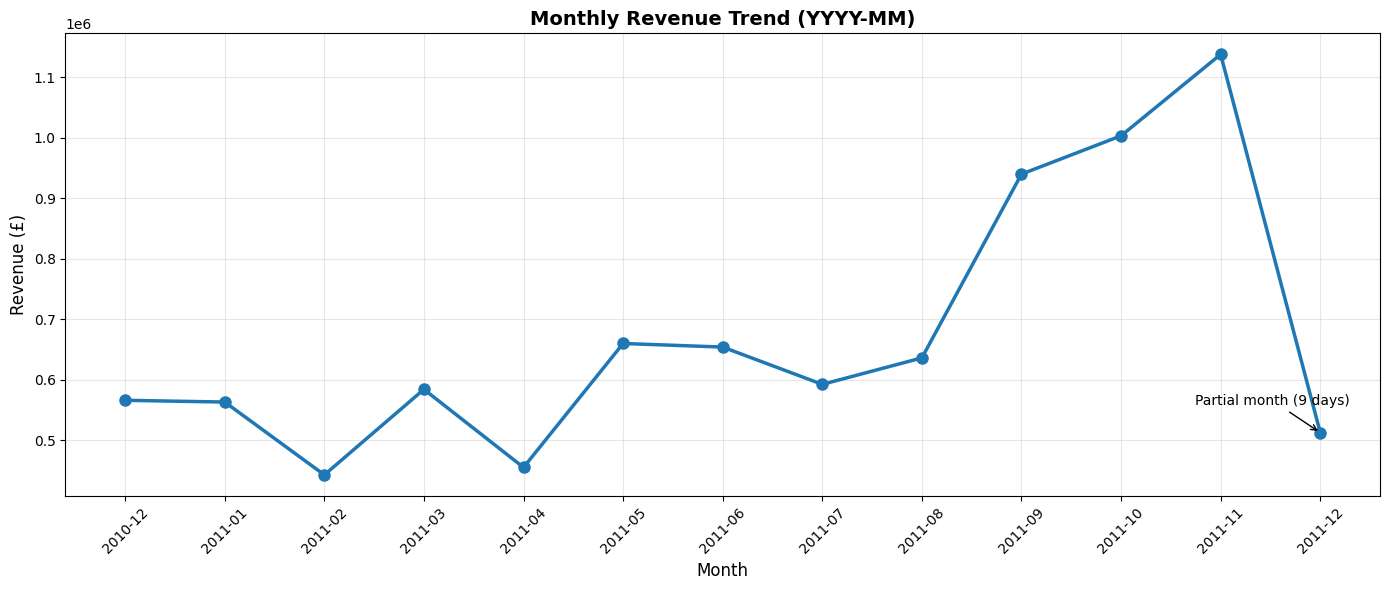


→ Creating Hourly Purchasing Patterns chart...


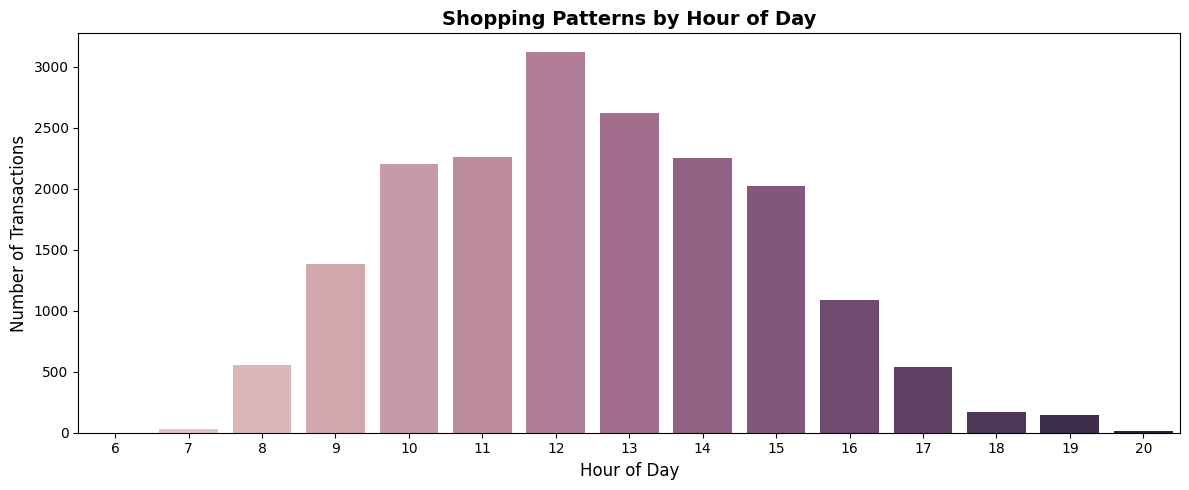


→ Creating Customer Type Over Time chart...


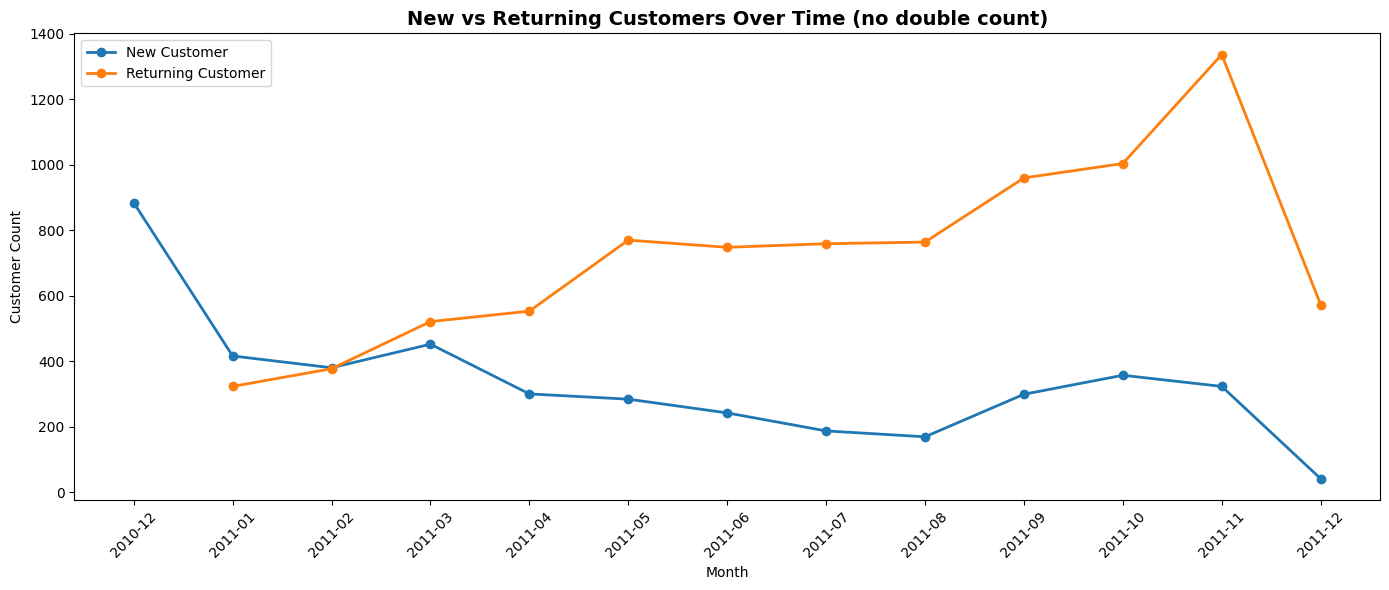

In [26]:
print("\n" + "\u2014" * 60)
print("[STEP 10] EXPLORATORY VISUALIZATIONS")
print("\u2014" * 60)

# 10.1  Monthly Revenue Trend
print("\n\u2192 Creating Monthly Revenue Trend chart...")

monthly = df.groupby(df["InvoiceDate"].dt.to_period("M")).agg(
    Revenue   = ("Revenue",     "sum"),
    Orders    = ("InvoiceNo",   "nunique"),
    Customers = ("CustomerID",  "nunique"),
    FirstDate = ("InvoiceDate", "min"),
    LastDate  = ("InvoiceDate", "max"),
)
monthly["DaysCovered"] = (monthly["LastDate"] - monthly["FirstDate"]).dt.days + 1
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly.index, monthly["Revenue"].values, marker="o", linewidth=2.5, markersize=8)
ax.set_title("Monthly Revenue Trend (YYYY-MM)", fontsize=14, fontweight="bold")
ax.set_ylabel("Revenue (\u00a3)", fontsize=12)
ax.set_xlabel("Month", fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=45)

last_m = monthly.index[-1]
ax.annotate(
    f"Partial month ({int(monthly.loc[last_m, 'DaysCovered'])} days)",
    xy=(len(monthly) - 1, monthly["Revenue"].iloc[-1]),
    xytext=(-90, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
)
plt.tight_layout()
plt.show()

# 10.2  Hourly Purchasing Patterns
# R8 fix: renumbered from 10.4 (gaps 10.2 / 10.3 eliminated)
print("\n\u2192 Creating Hourly Purchasing Patterns chart...")
hourly_sales = df.groupby(df["InvoiceDate"].dt.hour)["InvoiceNo"].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
# N1 fix: hue= + legend=False suppresses seaborn FutureWarning
sns.barplot(
    x=hourly_sales.index,
    y=hourly_sales.values,
    hue=hourly_sales.index,
    legend=False,
    ax=ax,
)
ax.set_title("Shopping Patterns by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Number of Transactions", fontsize=12)
plt.tight_layout()
plt.show()

# 10.3  New vs Returning Customers Over Time
# R8 fix: renumbered from 10.5
print("\n\u2192 Creating Customer Type Over Time chart...")

cust_month  = df.drop_duplicates(["YearMonth", "CustomerID"])[["YearMonth", "CustomerID"]].copy()
first_month = df.groupby("CustomerID")["YearMonth"].min()

cust_month["CustomerType_Month"] = np.where(
    cust_month["YearMonth"] == cust_month["CustomerID"].map(first_month),
    "New Customer",
    "Returning Customer",
)
cust_counts = (
    cust_month.groupby(["YearMonth", "CustomerType_Month"])["CustomerID"]
    .nunique()
    .reset_index(name="CustomerCount")
)
cust_counts["YearMonth_str"] = cust_counts["YearMonth"].astype(str)

monthly_sum = cust_counts.groupby("YearMonth")["CustomerCount"].sum()
true_unique = df.groupby("YearMonth")["CustomerID"].nunique()

# RC5 fix: == not <= (new + returning must EQUAL total unique, not merely be <=;
#           the <= form passed silently on undercounting bugs)
assert (monthly_sum == true_unique).all(), \
    "New + Returning counts do not sum to total unique customers per month!"

fig, ax = plt.subplots(figsize=(14, 6))
for ctype in ["New Customer", "Returning Customer"]:
    data = cust_counts[cust_counts["CustomerType_Month"] == ctype]
    ax.plot(data["YearMonth_str"], data["CustomerCount"],
            marker="o", linewidth=2, label=ctype)

ax.set_title("New vs Returning Customers Over Time (no double count)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Customer Count")
ax.set_xlabel("Month")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SECTION 11: SEGMENT VISUALIZATIONS
# ------------------------------------------------------------



→ Creating Segment Counts chart...


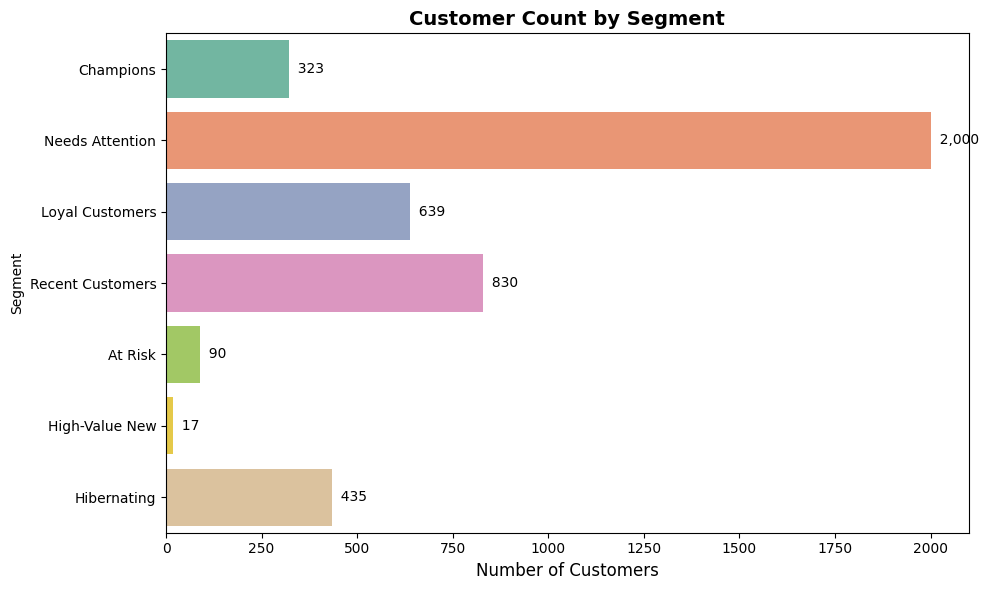


→ Creating Segment Revenue Contribution chart...


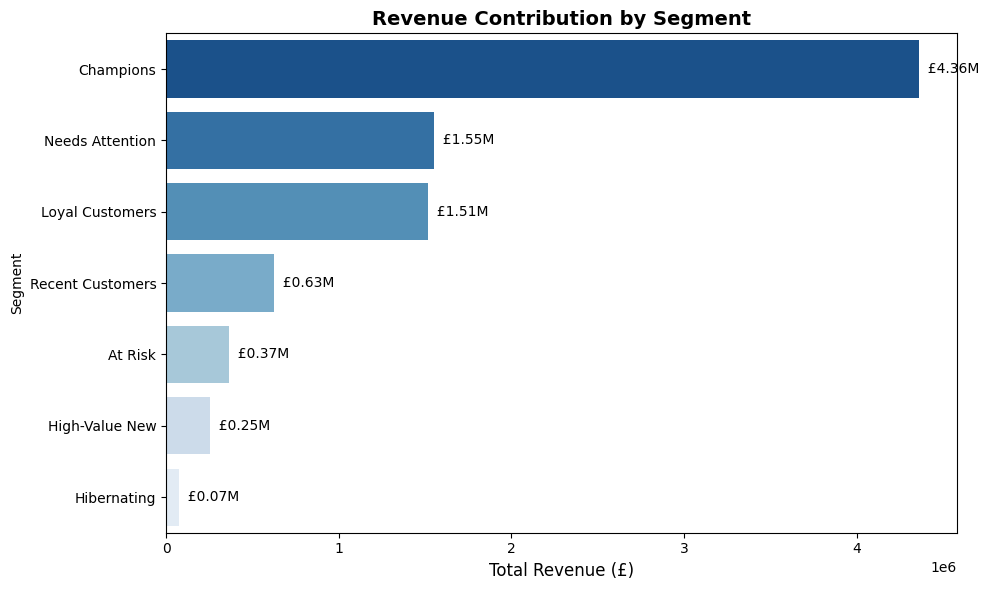


→ Creating R, F, M distributions chart...


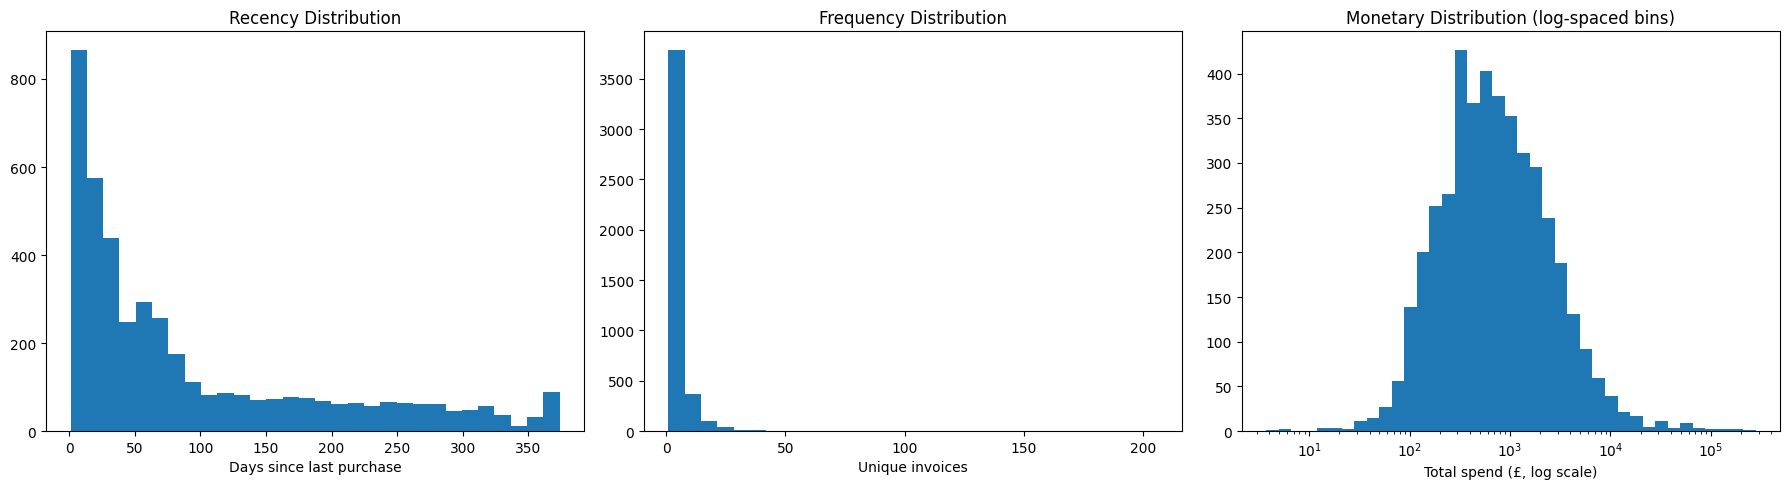


→ Creating Frequency vs Monetary scatter plot...


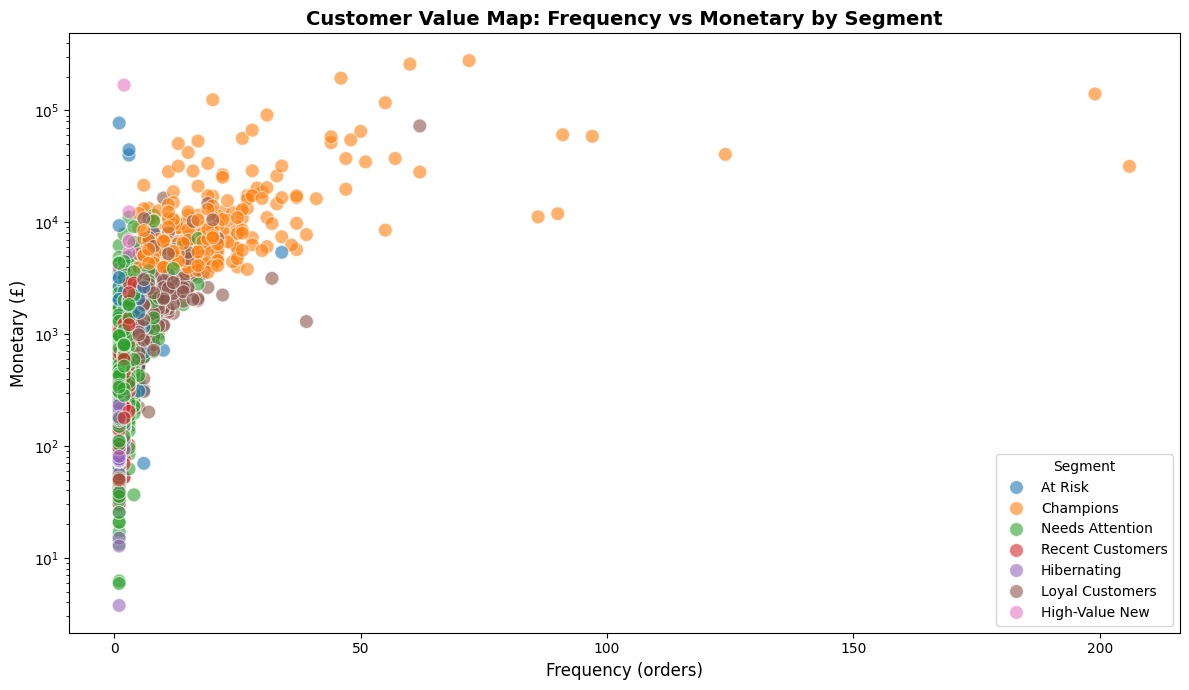

In [27]:
# 11.1  Segment Counts
print("\n\u2192 Creating Segment Counts chart...")
fig, ax = plt.subplots(figsize=(10, 6))

segment_counts = rfm["Segment"].value_counts().reindex(segment_summary.index)

# N1 fix: hue= + legend=False \u2014 palette without hue is removed in seaborn 0.14.0
sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index,
    hue=segment_counts.index,
    legend=False,
    ax=ax,
    palette="Set2",
)
ax.set_title("Customer Count by Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Customers", fontsize=12)
for i, v in enumerate(segment_counts.values):
    ax.text(v, i, f"  {v:,}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

# 11.2  Segment Revenue Contribution
print("\n\u2192 Creating Segment Revenue Contribution chart...")
fig, ax = plt.subplots(figsize=(10, 6))

seg_rev = segment_summary["Total_Monetary"].sort_values(ascending=False)

# N1 fix: hue= + legend=False
sns.barplot(
    x=seg_rev.values,
    y=seg_rev.index,
    hue=seg_rev.index,
    legend=False,
    ax=ax,
    palette="Blues_r",
)
ax.set_title("Revenue Contribution by Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (\u00a3)", fontsize=12)
for i, v in enumerate(seg_rev.values):
    ax.text(v, i, f"  \u00a3{v/1_000_000:.2f}M", va="center", fontsize=10)
plt.tight_layout()
plt.show()

# 11.3  R, F, M Distributions
print("\n\u2192 Creating R, F, M distributions chart...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm["Recency"],   bins=30)
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last purchase")

axes[1].hist(rfm["Frequency"], bins=30)
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Unique invoices")

m    = rfm["Monetary"].dropna()
m    = m[m > 0]
bins = np.logspace(np.log10(m.min()), np.log10(m.max()), 40)
axes[2].hist(m, bins=bins)
axes[2].set_xscale("log")
axes[2].set_title("Monetary Distribution (log-spaced bins)")
axes[2].set_xlabel("Total spend (\u00a3, log scale)")

plt.tight_layout()
plt.show()

# 11.4  Frequency vs Monetary by Segment
print("\n\u2192 Creating Frequency vs Monetary scatter plot...")
fig, ax = plt.subplots(figsize=(12, 7))   # minor fix: removed spurious double parentheses

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Segment",
                alpha=0.6, s=100, ax=ax)
ax.set_title("Customer Value Map: Frequency vs Monetary by Segment",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Frequency (orders)", fontsize=12)
ax.set_ylabel("Monetary (\u00a3)", fontsize=12)
ax.set_yscale("log")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SECTION 12: DECILE VISUALIZATIONS
# ------------------------------------------------------------



————————————————————————————————————————————————————————————
[STEP 12] DECILE VISUALIZATIONS
————————————————————————————————————————————————————————————

→ Creating Revenue by Decile chart...


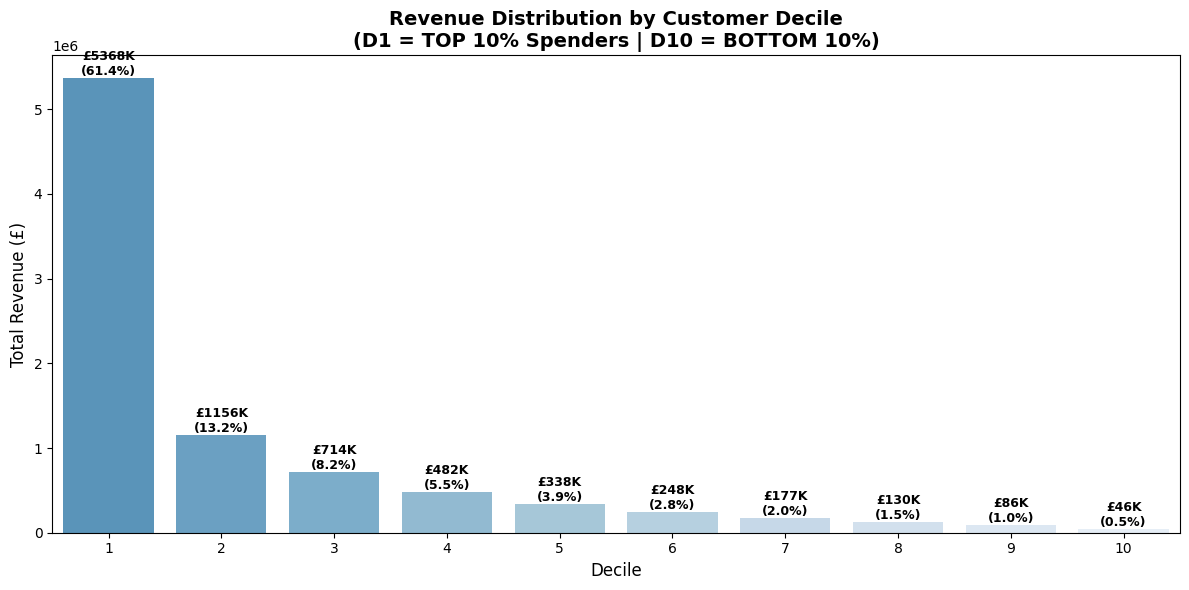


→ Creating Cumulative Revenue chart...


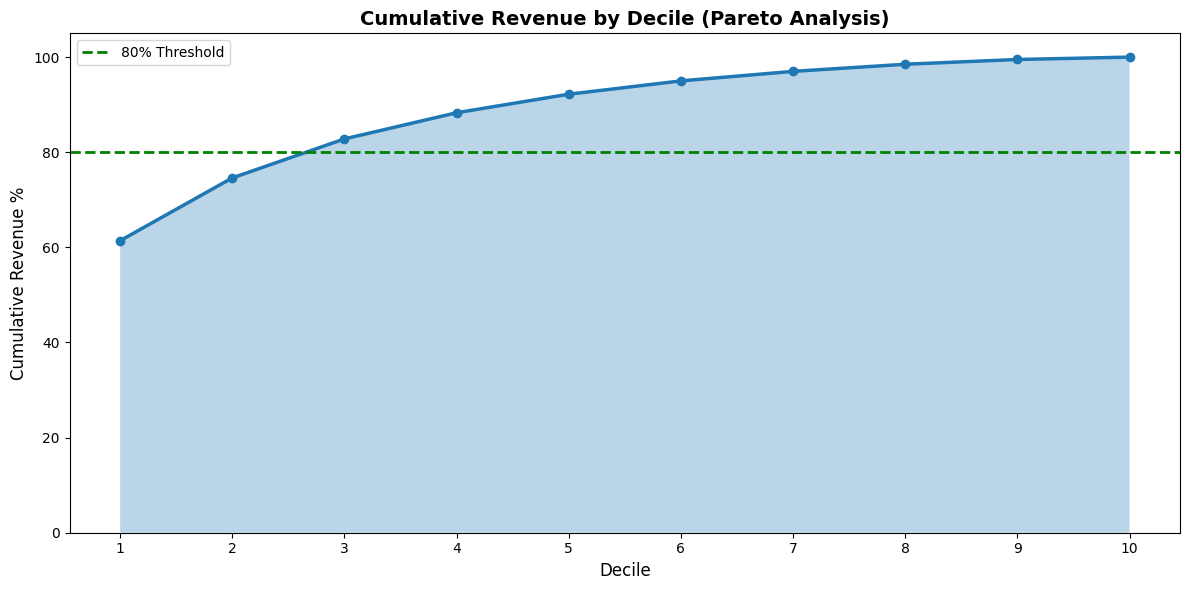

In [28]:
print("\n" + "\u2014" * 60)
print("[STEP 12] DECILE VISUALIZATIONS")
print("\u2014" * 60)

# 12.1  Revenue by Decile
print("\n\u2192 Creating Revenue by Decile chart...")
fig, ax = plt.subplots(figsize=(12, 6))

deciles_sorted = deciles.sort_index(ascending=True)

# N2 fix: convert numpy ndarray to list
# (numpy array palette raises UserWarning now, hard error in seaborn 0.14.0)
colors = list(plt.cm.Blues_r(np.linspace(0.4, 0.9, len(deciles_sorted))))

# N1 fix: hue= + legend=False
sns.barplot(
    x=deciles_sorted.index,
    y=deciles_sorted["TotalRevenue"],
    hue=deciles_sorted.index,
    legend=False,
    ax=ax,
    palette=colors,
)
ax.set_title(
    "Revenue Distribution by Customer Decile\n(D1 = TOP 10% Spenders | D10 = BOTTOM 10%)",
    fontsize=14, fontweight="bold",
)
ax.set_xlabel("Decile", fontsize=12)
ax.set_ylabel("Total Revenue (\u00a3)", fontsize=12)

for i, (idx, row) in enumerate(deciles_sorted.iterrows()):
    ax.text(
        i, row["TotalRevenue"],
        f"\u00a3{row['TotalRevenue']/1000:.0f}K\n({row['Revenue_%']:.1f}%)",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )
plt.tight_layout()
plt.show()

# 12.2  Cumulative Revenue by Decile (Pareto)
print("\n\u2192 Creating Cumulative Revenue chart...")
fig, ax = plt.subplots(figsize=(12, 6))

x = deciles_sorted.index.to_numpy()
y = deciles_sorted["CumRevenue_%"].to_numpy(dtype=float)

ax.plot(x, y, marker="o", linewidth=2.5)
ax.fill_between(x, y, alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(deciles_sorted.index.to_list())
ax.axhline(80, color="green", linestyle="--", linewidth=2, label="80% Threshold")
ax.set_title("Cumulative Revenue by Decile (Pareto Analysis)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Decile", fontsize=12)
ax.set_ylabel("Cumulative Revenue %", fontsize=12)
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()


In [29]:
# [STEP 13] BUDGET ALLOCATION FRAMEWORK
print("\n" + "\u2014" * 60)
print("[STEP 13] BUDGET ALLOCATION FRAMEWORK")
print("\u2014" * 60)

# RC7 fix: replaced the tautological Budget_% = Revenue_% (and the no-op rename)
#          with a real blended allocation model.
#
# Model: Blended Revenue + Growth-Uplift
# ──────────────────────────────────────
# REVENUE_WEIGHT (55%): allocate proportional to current customer value
#   \u2192 protects Champions and Loyal Customers
#
# GROWTH_WEIGHT  (45%): allocate proportional to growth-uplift potential
#   GrowthUplift_D = revenue share NOT yet captured by deciles D1..(D-1)
#   (D10 has the most headroom; D1 has already captured its share)
#   Normalised so all uplift weights sum to 100.
#
# Effect:
#   D1  \u2014 budget dips slightly below revenue share (retention is cheap for loyal buyers)
#   D3\u2013D5 \u2014 growth premium (highest expected ROI for upsell / conversion)
#   D8\u201310 \u2014 minimal spend (low value, low growth potential)
#
REVENUE_WEIGHT = 0.55
GROWTH_WEIGHT  = 0.45

budget_alloc = deciles[["TotalRevenue", "Revenue_%", "CumRevenue_%"]].copy()

cum_prev = budget_alloc["CumRevenue_%"].shift(1, fill_value=0.0)
budget_alloc["GrowthUplift"]   = (100.0 - cum_prev).clip(lower=0)
budget_alloc["GrowthUplift_%"] = (
    budget_alloc["GrowthUplift"] / budget_alloc["GrowthUplift"].sum() * 100
).round(2)

budget_alloc["Budget_raw"] = (
    REVENUE_WEIGHT * budget_alloc["Revenue_%"]
    + GROWTH_WEIGHT  * budget_alloc["GrowthUplift_%"]
)
budget_alloc["Budget_%"] = (
    budget_alloc["Budget_raw"] / budget_alloc["Budget_raw"].sum() * 100
).round(1)

budget_alloc = budget_alloc[["Revenue_%", "GrowthUplift_%", "Budget_%"]]

print(f"\nAllocation model : {REVENUE_WEIGHT*100:.0f}% revenue weight + {GROWTH_WEIGHT*100:.0f}% growth-uplift weight")
print("\nMarketing Budget Allocation by Decile:")
print(budget_alloc.round(1))
print(f"\nTotal Budget_% : {budget_alloc['Budget_%'].sum():.1f}%")
print("\nInsight: D1 budget is below its revenue share (retention is cheaper than acquisition).")
print("D3\u2013D5 receive a growth premium \u2014 highest ROI zone for upsell and conversion campaigns.")



————————————————————————————————————————————————————————————
[STEP 13] BUDGET ALLOCATION FRAMEWORK
————————————————————————————————————————————————————————————

Allocation model : 55% revenue weight + 45% growth-uplift weight

Marketing Budget Allocation by Decile:
        Revenue_%  GrowthUplift_%  Budget_%
Decile                                     
1            61.4            47.5      55.1
2            13.2            18.3      15.5
3             8.2            12.1       9.9
4             5.5             8.2       6.7
5             3.9             5.6       4.6
6             2.8             3.7       3.2
7             2.0             2.4       2.2
8             1.5             1.4       1.5
9             1.0             0.7       0.9
10            0.5             0.2       0.4

Total Budget_% : 100.0%

Insight: D1 budget is below its revenue share (retention is cheaper than acquisition).
D3–D5 receive a growth premium — highest ROI zone for upsell and conversion campaigns.


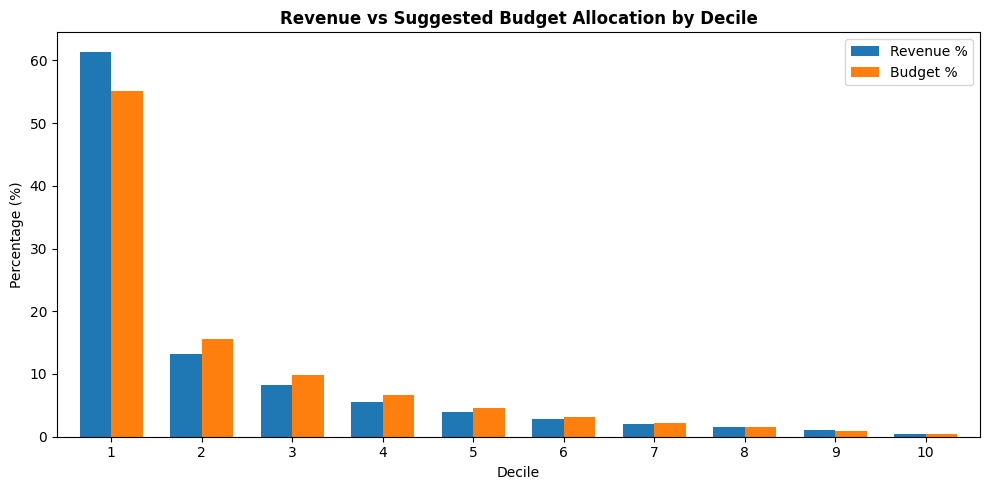

In [30]:
# R9 fix: removed the unreachable `if plt is not None:` guard
# (plt is imported unconditionally in Section 1; the condition is always True)

fig, ax = plt.subplots(figsize=(10, 5))

# Side-by-side comparison makes the allocation shift visible at a glance
budget_alloc[["Revenue_%", "Budget_%"]].plot(kind="bar", ax=ax, width=0.7)
ax.set_title("Revenue vs Suggested Budget Allocation by Decile", fontweight="bold")
ax.set_xlabel("Decile")
ax.set_ylabel("Percentage (%)")
ax.legend(["Revenue %", "Budget %"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
